# Background tutorial

In this tutorial you will familiarize with reading DICOM images, and refresh a number of concepts regarding showing image and signal pre-processing

First thing, you'll read a 2D DICOM image, specifically chest X-rays.
Data come from the "The Society for Imaging Informatics in Medicine (SIIM) and the American College of Radiology (ACR)" pneuomothorax imaging challenge https://siim.org/page/pneumothorax_challenge
The scope was to invent an algoritm to automatically detect ("segment") a pneuomthorax area in the image, if present.

## Imports

List of libraries we will use

In [3]:
from pydicom import dcmread  # tool to read dicom files. Need to
import pydicom.errors  # in case we need to do some error handling
import os  # tools to deal with paths
import glob  # find files recursively
import numpy as np  # matrix manipulation
import matplotlib.pyplot as plt  # plotting


# Task 1: Dicom files reading and handling

Read using dcmread the file 'dicom_immTest.dcm'
documentation: https://pydicom.github.io/pydicom/dev/reference/generated/pydicom.filereader.dcmread.html

Print everything that is inside and look at the headers:

Identify patient name, age, sex, body part examined

Identify the image dimensions (rows and columns)

What is the sampling spacing between the pixels? How many bits are used in each pixel?

(BTW, you can also iterate on what is returned by dcmread)

In [4]:
dcmHead = dcmread("dicom_immTest.dcm")

print("Patient Name:     ", dcmHead.PatientName)
print("Patient Age:      ", dcmHead.PatientAge)
print("Patient Sex:      ", dcmHead.PatientSex)
print("Body Part:        ", dcmHead.BodyPartExamined)
print("Rows x Cols:      ", dcmHead.Rows, "x", dcmHead.Columns)
print("Pixel Spacing:    ", dcmHead.PixelSpacing)
print("Bits Allocated:   ", dcmHead.BitsAllocated)

Patient Name:      88c14312-3265-4a3f-b7bb-41818107d607
Patient Age:       58
Patient Sex:       F
Body Part:         CHEST
Rows x Cols:       1024 x 1024
Pixel Spacing:     [0.139, 0.139]
Bits Allocated:    8


## Task 1.1: Display the image

The image data are stored in the field "pixel_array", which returns a numpy array.

Think: which data format you expect? Which array shape you expect? (find this in the dicom headers)

Once you do this, show the image using matplotlib.pyplot and imshow

Shape: (1024, 1024) Data Type: uint8


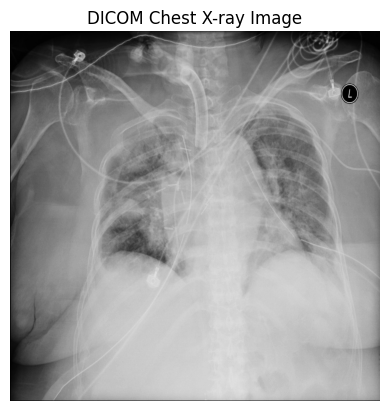

In [5]:
pixel_array = dcmHead.pixel_array
print("Shape:", pixel_array.shape, "Data Type:", pixel_array.dtype)

plt.imshow(pixel_array, cmap="gray")
plt.title("DICOM Chest X-ray Image")
plt.axis("off")
plt.show()

## Task 1.2: optimize the visualization

Does this look good?

Show the image: bigger (plt figsize parameter or zoom in a specific range), choosing a good colormap. Disable axis ticks (plt.axis('off')). Use the plt.imshow options cmap, vmin,vmax

Think! How many pixels is the image wide? How big can you go in showing it? Use the "interp" option and get an idea of its effect in practice (especially between none/None/nearest, and bilinear)

By the way, open the plt.imshow documentation and look at the description of the colormaps. Get an idea of their effect




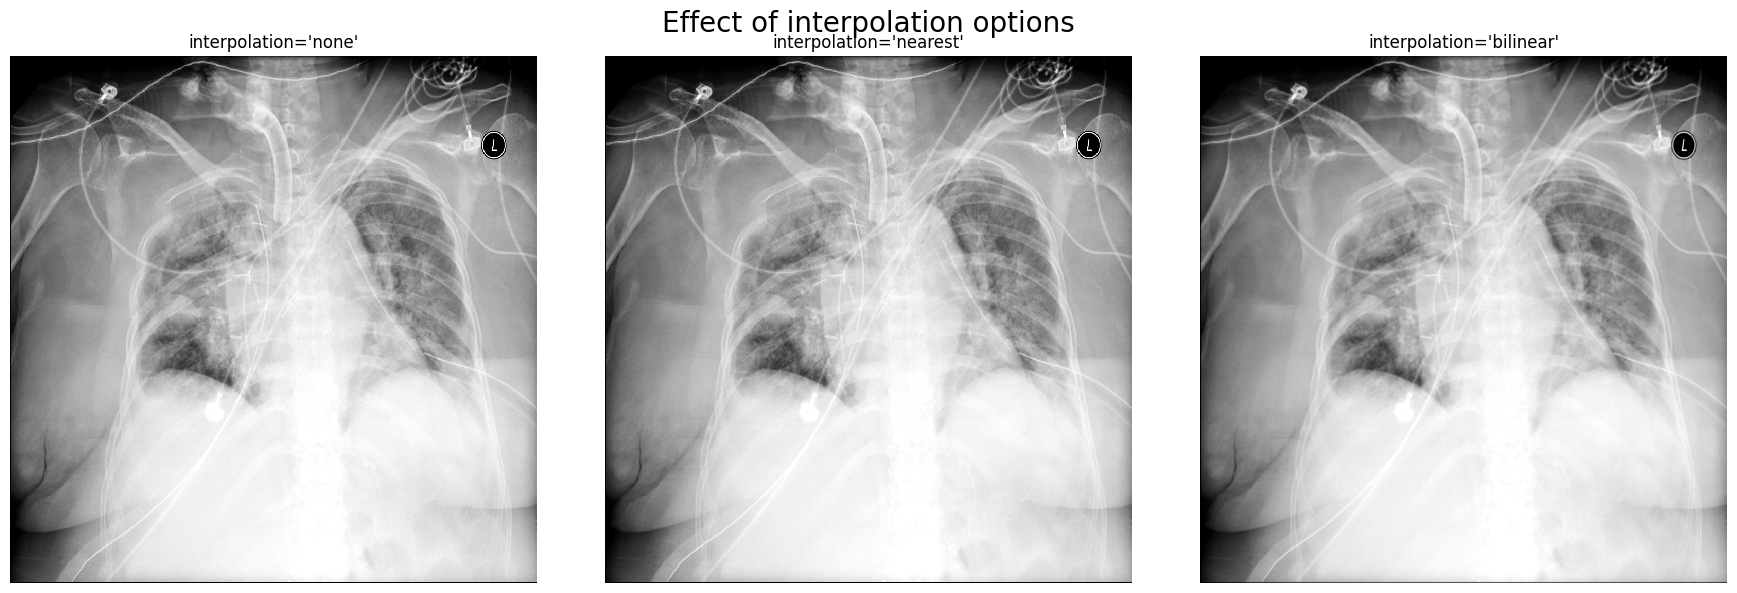

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# vmin/vmax: clip intensity range to improve contrast
# typical chest X-ray windowing
vmin, vmax = np.percentile(pixel_array, [2, 98])

interp_options = ["none", "nearest", "bilinear"]

for ax, interp in zip(axes, interp_options):
    ax.imshow(pixel_array, cmap="gray", vmin=vmin, vmax=vmax, interpolation=interp)
    ax.set_title(f"interpolation='{interp}'")
    ax.axis("off")

plt.suptitle("Effect of interpolation options", fontsize=20)
plt.tight_layout()
plt.show()

In [7]:
# IMPORTANT NOTE:
# This section does not work on VSCode but it works on Jupyter Notebook on the browser. It allows you to interactively adjust the windowing and colormap of the image.

from ipywidgets import interact, IntSlider


def show_image(vmin, vmax, cmap):
    plt.figure(figsize=(8, 8))
    plt.imshow(pixel_array, cmap=cmap, vmin=vmin, vmax=vmax, interpolation="bilinear")
    plt.axis("off")
    plt.show()


pmin, pmax = int(pixel_array.min()), int(pixel_array.max())

interact(
    show_image,
    vmin=IntSlider(min=pmin, max=pmax, step=10, value=pmin),
    vmax=IntSlider(min=pmin, max=pmax, step=10, value=pmax),
    cmap=["gray", "bone", "hot", "jet", "viridis"],
)

interactive(children=(IntSlider(value=0, description='vmin', max=255, step=10), IntSlider(value=255, descripti…

<function __main__.show_image(vmin, vmax, cmap)>

# Task 2: Effects of noise, noise metrics

- Take the image, add a random vector (eg: np.random.normal, but there are many other image-specific function), and see what it looks like. BTW, which format is the input image? What happens if you sum np.random.normal?
- How much noise do you need to add before you notice it?
- Try displaying only a section of the image, is the impact of the same level of noise the same?
- Compute the MSE


## My answers

- The image is of type uint16, which has a max value of 65535. If a pixel is at 60000 and you add noise of +10000, it wraps around to a small number instead of clipping — you get completely wrong values silently.
- It gets easily noticed with sigma = 30
- The visual impact of the noise is bigger as we zoom into the image.
- However, the MSE is very similar

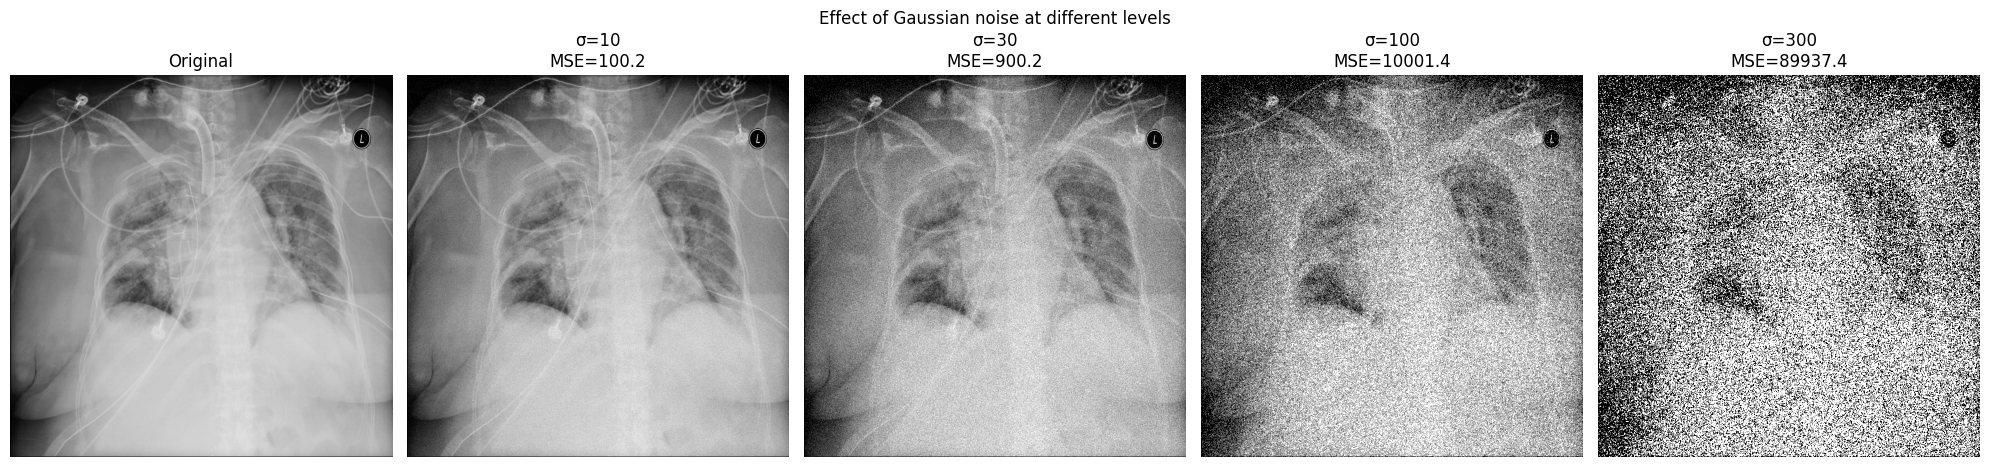

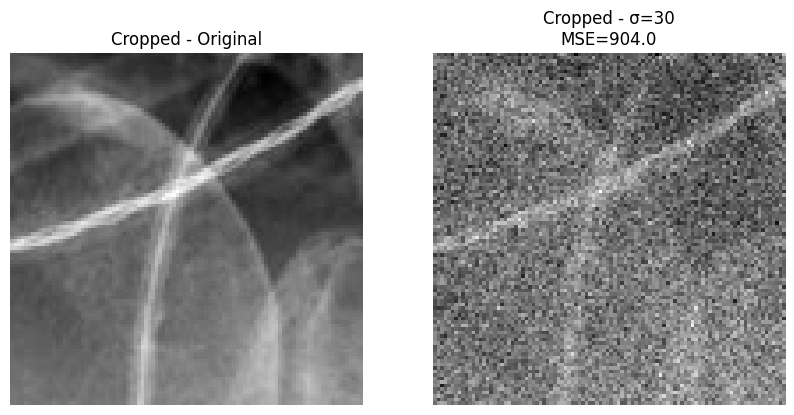

In [21]:
# the image is uint16 - need to convert to float for adding noise
img = pixel_array.astype(np.float32)

# --- Add noise at different levels ---
noise_levels = [10, 30, 100, 300]

fig, axes = plt.subplots(1, len(noise_levels) + 1, figsize=(20, 5))

axes[0].imshow(img, cmap="gray", vmin=img.min(), vmax=img.max())
axes[0].set_title("Original")
axes[0].axis("off")

for ax, sigma in zip(axes[1:], noise_levels):
    noise = np.random.normal(0, sigma, img.shape)
    noisy = img + noise
    mse = np.mean((img - noisy) ** 2)
    ax.imshow(noisy, cmap="gray", vmin=img.min(), vmax=img.max())
    ax.set_title(f"σ={sigma}\nMSE={mse:.1f}")
    ax.axis("off")

plt.suptitle("Effect of Gaussian noise at different levels")
plt.tight_layout()
plt.show()

# --- Zoom into a small region to see noise impact ---
crop = img[100:200, 100:200]  # adjust coordinates as needed
sigma = 30
noisy_crop = crop + np.random.normal(0, sigma, crop.shape)
mse_crop = np.mean((crop - noisy_crop) ** 2)


fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(crop, cmap="gray")
axes[0].set_title("Cropped - Original")
axes[1].imshow(noisy_crop, cmap="gray")
axes[1].set_title(f"Cropped - σ={sigma}\nMSE={mse_crop:.1f}")
for ax in axes:
    ax.axis("off")
plt.show()

# Task 3: Image processing, gaussian filtering

Once you are familiar with reading the image, familiarize yourself with processing images.
Let's start by denoising the image using gaussian filtering.
Use scipy.ndimage.gaussian_filter (import scipy.ndimage as ndi)

Define the sigma parameter in mm (the function requires it in pixels). Try sigma values only smaller than 1 mm (why?)

BTW, which is the lowest sigma value that makes sense?

Compute MSE as a function of filtering strength

In [8]:
import scipy.ndimage as ndi

ModuleNotFoundError: No module named 'scipy'

Show the image before and after convolution, side by side.

Can you spot the differences?

If you do not see differences, what happens if you zoom in?

### Bonus Task: what happens if you subtract filtered and unfiltered images?

What happens if you subtract the original image from the convolved one?

1. Are you able to do the subraction? If not how can you fix that?
1. Do you see anything? If not, what do you need to tweak?
1. What do you see as a function of sigma?

# Task 3: Resample the image


### Task 3.1: downsample the image to a 256x256
e.g.:use skimage.transform.resize or scipy.ndimage.zoom

Go on the documentation and read the options you can pass!!


### Task 3.2: upsample a small region of the image (e.g.: from pixel 400 to 500 along both axes) at 50x50 um^2 pixel size

Use the same functions as before

Notice how deep we can go into upsampling before we lose image quality. Think about whether this makes sense by calculating how many pixels plt.figure is using!

When displaying the image pyplot.imshow might apply interpolation. Be sure to pass the parameter "interpolation=none"